# IT5006 Crime Prediction Project: Baseline Modeling Notebook

## 1. Project objective and task definition

This notebook builds and compares two baseline models for **binary crime risk prediction**:

1. Logistic Regression
2. Random Forest

**Prediction target**: For each **Community Area + Week** at time `t`, predict whether that community area will be **high-risk at week `t+1`**.

**High-risk definition**: A community area is labeled high-risk for a given week if its crime count for that week is at or above the **75th percentile** of crime counts across all community areas for the same week.

This percentile-based definition focuses on relative hotspot risk rather than absolute crime counts, which better matches resource prioritization in predictive policing.

**Feature rationale**:
- THEFT, BATTERY, and BURGLARY counts are included because these categories are among the most frequent and stable crime types in the dataset, making them suitable for weekly risk modeling.
- Community Area is modeled as a categorical feature; one-hot encoding allows the models to capture spatial heterogeneity across different neighborhoods.

**Scope constraints followed in this notebook**:
- Uses only `chicago_crime_2015_2024_enriched.parquet`
- Training/validation workflow only (no final test set for model selection)
- Time-based split for model development
- Report-friendly structure with markdown explanations and saved handoff artifacts


## 2. Load dataset


In [10]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid

import joblib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

DATA_PATH = Path('chicago_crime_2015_2024_enriched.parquet')
assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH.resolve()}'

# Main modeling source (required): single parquet dataset
try:
    df_raw = pd.read_parquet(DATA_PATH)
except Exception as e:
    raise RuntimeError(
        f'Unable to read parquet file {DATA_PATH}. '
        'Please confirm parquet integrity / engine compatibility before proceeding.'
    ) from e

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head()


Shape: (2519279, 12)
Columns: ['Date', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Community Area', 'Community_Name', 'Year', 'Month', 'Day_of_Week', 'Hour']


,Date,Primary Type,Description,Location Description,Arrest,Domestic,Community Area,Community_Name,Year,Month,Day_of_Week,Hour
0,2024-12-31 23:58:00,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,43,SOUTH SHORE,2024,12,Tuesday,23
1,2024-12-31 23:56:00,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,38,GRAND BOULEVARD,2024,12,Tuesday,23
2,2024-12-31 23:55:00,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,70,ASHBURN,2024,12,Tuesday,23
3,2024-12-31 23:53:00,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,42,WOODLAWN,2024,12,Tuesday,23
4,2024-12-31 23:50:00,BATTERY,SIMPLE,SIDEWALK,False,False,25,AUSTIN,2024,12,Tuesday,23



## 3. Data inspection and cleaning checks

This section verifies expected columns, enforces data types, and removes records with missing critical keys (`Date`, `Community Area`).


In [11]:

required_cols = [
    'Date',
    'Primary Type',
    'Location Description',
    'Arrest',
    'Domestic',
    'Community Area',
]

missing = [c for c in required_cols if c not in df_raw.columns]
assert not missing, f'Missing required columns: {missing}'

df = df_raw.copy()

# Type normalization
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Community Area'] = pd.to_numeric(df['Community Area'], errors='coerce')

for bcol in ['Arrest', 'Domestic']:
    if bcol in df.columns:
        df[bcol] = df[bcol].astype('float')

# Keep usable records only
df = df.dropna(subset=['Date', 'Community Area'])
df['Community Area'] = df['Community Area'].astype(int)

# Standardize text columns used in aggregation
for tcol in ['Primary Type', 'Location Description']:
    # Convert to pandas string dtype first to avoid Categorical fillna category errors.
    s = df[tcol].astype('string')
    s = s.fillna('UNKNOWN').str.strip()
    s = s.replace('', 'UNKNOWN')
    df[tcol] = s

print('Cleaned shape:', df.shape)
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Unique community areas:', df['Community Area'].nunique())

df[['Date', 'Community Area', 'Primary Type', 'Location Description', 'Arrest', 'Domestic']].head()


Cleaned shape: (2519279, 12)
Date range: 2015-01-01 00:00:00 to 2024-12-31 23:58:00
Unique community areas: 77


,Date,Community Area,Primary Type,Location Description,Arrest,Domestic
0,2024-12-31 23:58:00,43,CRIMINAL DAMAGE,APARTMENT,0.0,0.0
1,2024-12-31 23:56:00,38,CRIMINAL TRESPASS,APARTMENT,1.0,1.0
2,2024-12-31 23:55:00,70,BATTERY,HOTEL / MOTEL,0.0,1.0
3,2024-12-31 23:53:00,42,CRIMINAL DAMAGE,STREET,0.0,0.0
4,2024-12-31 23:50:00,25,BATTERY,SIDEWALK,0.0,0.0


## 4. Aggregate data by Community Area and Week

Unit of analysis is `Community Area + Week`.
Weeks are defined as **Monday-start weeks**.

Weekly aggregation includes:
- total crime count
- theft count
- battery count
- burglary count
- arrest rate
- domestic rate
- top location description frequency (share of weekly incidents in the most frequent location type)

In [12]:

# Anchor each record to Monday-start week (W-SUN periods start on Monday)
df['week_start'] = df['Date'].dt.to_period('W-SUN').dt.start_time

# Crime-type indicator flags
crime_type = df['Primary Type'].str.upper()
df['is_theft'] = (crime_type == 'THEFT').astype(int)
df['is_battery'] = (crime_type == 'BATTERY').astype(int)
df['is_burglary'] = (crime_type == 'BURGLARY').astype(int)

base_weekly = (
    df.groupby(['Community Area', 'week_start'], as_index=False)
      .agg(
          total_crime_count=('Primary Type', 'size'),
          theft_count=('is_theft', 'sum'),
          battery_count=('is_battery', 'sum'),
          burglary_count=('is_burglary', 'sum'),
          arrest_rate=('Arrest', 'mean'),
          domestic_rate=('Domestic', 'mean'),
      )
)

# Frequency of most common location description in each area-week
loc_counts = (
    df.groupby(['Community Area', 'week_start', 'Location Description'])
      .size()
      .reset_index(name='loc_count')
)

top_loc_freq = (
    loc_counts
    .sort_values(['Community Area', 'week_start', 'loc_count'], ascending=[True, True, False])
    .drop_duplicates(['Community Area', 'week_start'])
    .rename(columns={'loc_count': 'top_location_count'})
    [['Community Area', 'week_start', 'top_location_count']]
)

weekly = base_weekly.merge(top_loc_freq, on=['Community Area', 'week_start'], how='left')
weekly['top_location_freq'] = weekly['top_location_count'] / weekly['total_crime_count']
weekly = weekly.drop(columns=['top_location_count'])

weekly = weekly.sort_values(['Community Area', 'week_start']).reset_index(drop=True)
weekly.head()


,Community Area,week_start,total_crime_count,theft_count,battery_count,burglary_count,arrest_rate,domestic_rate,top_location_freq
0,1,2014-12-30,50,7,14,0,0.220000,0.360000,0.26
1,1,2015-01-06,47,14,4,5,0.191489,0.042553,0.212766
2,1,2015-01-13,77,17,16,2,0.337662,0.168831,0.311688
3,1,2015-01-20,74,18,17,3,0.391892,0.175676,0.243243
4,1,2015-01-27,71,19,16,2,0.211268,0.154930,0.28169


## 5. Feature engineering

Additional temporal features:
- calendar: `month`, `week_of_year`
- lags: `lag_1`, `lag_2`
- rolling summaries: `rolling_mean_4`, `rolling_mean_8`

Lag/rolling features are computed separately within each Community Area and shifted to avoid using same-week target information.

THEFT, BATTERY, and BURGLARY are used as weekly count features because they are frequent and comparatively stable categories for baseline risk modeling.

In [13]:
weekly['month'] = weekly['week_start'].dt.month
weekly['week_of_year'] = weekly['week_start'].dt.isocalendar().week.astype(int)

weekly = weekly.sort_values(['Community Area', 'week_start']).copy()

weekly['lag_1'] = weekly.groupby('Community Area')['total_crime_count'].transform(lambda s: s.shift(1))
weekly['lag_2'] = weekly.groupby('Community Area')['total_crime_count'].transform(lambda s: s.shift(2))
weekly['rolling_mean_4'] = weekly.groupby('Community Area')['total_crime_count'].transform(
    lambda s: s.shift(1).rolling(window=4, min_periods=1).mean()
)
weekly['rolling_mean_8'] = weekly.groupby('Community Area')['total_crime_count'].transform(
    lambda s: s.shift(1).rolling(window=8, min_periods=1).mean()
)

weekly.head(10)

,Community Area,week_start,total_crime_count,theft_count,battery_count,burglary_count,arrest_rate,domestic_rate,top_location_freq,month,week_of_year,lag_1,lag_2,rolling_mean_4,rolling_mean_8
0,1,2014-12-30,50,7,14,0,0.220000,0.360000,0.26,12,1,<NA>,<NA>,NaN,NaN
1,1,2015-01-06,47,14,4,5,0.191489,0.042553,0.212766,1,2,50,<NA>,50.00,50.000000
2,1,2015-01-13,77,17,16,2,0.337662,0.168831,0.311688,1,3,47,50,48.50,48.500000
3,1,2015-01-20,74,18,17,3,0.391892,0.175676,0.243243,1,4,77,47,58.00,58.000000
4,1,2015-01-27,71,19,16,2,0.211268,0.154930,0.28169,1,5,74,77,62.00,62.000000
5,1,2015-02-03,68,16,9,3,0.205882,0.132353,0.279412,2,6,71,74,67.25,63.800000
6,1,2015-02-10,65,14,13,0,0.307692,0.307692,0.246154,2,7,68,71,72.50,64.500000
7,1,2015-02-17,54,12,12,7,0.296296,0.259259,0.37037,2,8,65,68,69.50,64.571429
8,1,2015-02-24,64,12,14,4,0.281250,0.156250,0.296875,2,9,54,65,64.50,63.250000
9,1,2015-03-03,54,5,15,2,0.277778,0.203704,0.259259,3,10,64,54,62.75,65.000000


## 6. Label construction

For each row at week `t`:
- `next_week_crime_count` is the same community area's total crime count at week `t+1`
- high-risk threshold is the 75th percentile of crime counts across all community areas for week `t+1`
- binary label `is_high_risk_next_week` = 1 if `next_week_crime_count >= threshold(t+1)`

This percentile-based definition focuses on relative hotspot risk rather than absolute crime counts, which better matches resource prioritization in predictive policing.

In [14]:

# Next-week outcome per community area
weekly['next_week_crime_count'] = weekly.groupby('Community Area')['total_crime_count'].shift(-1)
weekly['target_week_start'] = weekly['week_start'] + pd.Timedelta(days=7)

# Weekly cross-sectional high-risk threshold (75th percentile)
week_threshold = (
    weekly.groupby('week_start', as_index=False)['total_crime_count']
    .quantile(0.75)
    .rename(columns={'week_start': 'target_week_start', 'total_crime_count': 'q75_next_week'})
)

weekly = weekly.merge(week_threshold, on='target_week_start', how='left')
weekly['is_high_risk_next_week'] = (
    weekly['next_week_crime_count'] >= weekly['q75_next_week']
).astype('float')

# Remove rows where next-week target is not available
model_df = weekly.dropna(subset=['next_week_crime_count', 'q75_next_week', 'is_high_risk_next_week']).copy()
model_df['is_high_risk_next_week'] = model_df['is_high_risk_next_week'].astype(int)

print('Modeling rows:', len(model_df))
print('Positive class rate:', model_df['is_high_risk_next_week'].mean().round(4))
model_df[['Community Area', 'week_start', 'next_week_crime_count', 'q75_next_week', 'is_high_risk_next_week']].head()


Modeling rows: 40185
Positive class rate: 0.2619


,Community Area,week_start,next_week_crime_count,q75_next_week,is_high_risk_next_week
0,1,2014-12-30,47,72.0,0
1,1,2015-01-06,77,82.0,0
2,1,2015-01-13,74,101.0,0
3,1,2015-01-20,71,90.0,0
4,1,2015-01-27,68,74.0,0


## 7. Train/validation split

Time-based split only:
- Train: 2015-01-01 to 2023-12-31
- Validation: 2024-01-01 to 2024-12-31

No final test set is used for model selection in this notebook.
The current parquet file covers 2015-2024 only, so future final test data (for example 2025+) is conceptually reserved for downstream evaluation and is not present here.

In [15]:
feature_cols = [
    'Community Area',
    'total_crime_count',
    'theft_count',
    'battery_count',
    'burglary_count',
    'arrest_rate',
    'domestic_rate',
    'top_location_freq',
    'month',
    'week_of_year',
    'lag_1',
    'lag_2',
    'rolling_mean_4',
    'rolling_mean_8',
]

target_col = 'is_high_risk_next_week'

model_df = model_df.sort_values('week_start').copy()

train_mask = (model_df['week_start'] >= '2015-01-01') & (model_df['week_start'] < '2024-01-01')
val_mask = (model_df['week_start'] >= '2024-01-01') & (model_df['week_start'] < '2025-01-01')
holdout_mask = model_df['week_start'] >= '2025-01-01'

train_df = model_df.loc[train_mask].copy()
val_df = model_df.loc[val_mask].copy()
holdout_df = model_df.loc[holdout_mask].copy()

assert len(train_df) > 0, 'Empty training split. Check date parsing / coverage.'
assert len(val_df) > 0, 'Empty validation split. Check date parsing / coverage.'

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

print('Train rows:', len(train_df), '| positive rate:', y_train.mean().round(4))
print('Validation rows:', len(val_df), '| positive rate:', y_val.mean().round(4))
print('Rows with week_start >= 2025-01-01 in this parquet:', len(holdout_df))
if holdout_df.empty:
    print('Note: holdout_df is empty because the current parquet dataset ends in 2024.')

Train rows: 36108 | positive rate: 0.2618
Validation rows: 4000 | positive rate: 0.2628
Untouched 2025+ rows: 0


### Class imbalance check

Class distributions are reported below for train and validation labels.
Class imbalance is handled through `class_weight` tuning in both models.

In [ ]:
print('y_train value counts:')
print(y_train.value_counts(dropna=False).sort_index())
print()
print('y_train class proportions:')
print(y_train.value_counts(normalize=True, dropna=False).sort_index())

print()
print('=' * 50)
print()

print('y_val value counts:')
print(y_val.value_counts(dropna=False).sort_index())
print()
print('y_val class proportions:')
print(y_val.value_counts(normalize=True, dropna=False).sort_index())

### Hyperparameter tuning methodology

Hyperparameter tuning is performed only with train/validation data.
No final test data is used for model selection.
Models are selected primarily by validation F1-score, with ROC-AUC as a secondary tie-breaker.
This avoids information leakage and preserves fairness for downstream testing.

## 8. Logistic Regression model

Logistic Regression is used as an interpretable baseline.

Model architecture:
- preprocessing: median imputation for numeric features, scaling of numeric features, and one-hot encoding of Community Area
- classifier: `LogisticRegression`

One-hot encoding allows the models to capture spatial heterogeneity across different neighborhoods.

### 10. Hyperparameter tuning (Logistic Regression)
Grid searched on validation performance:
- `C`: regularization strength inverse
- `class_weight`: class imbalance handling

In [16]:
categorical_features = ['Community Area']
numeric_features = [c for c in feature_cols if c not in categorical_features]

preprocess_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

def evaluate_binary(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

lr_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__class_weight': [None, 'balanced', {0: 1, 1: 2}],
}

lr_results = []
best_lr = None
best_lr_metrics = None
best_lr_params = None
best_lr_key = (-np.inf, -np.inf)

for params in ParameterGrid(lr_grid):
    lr_pipe = Pipeline(steps=[
        ('preprocess', preprocess_lr),
        ('model', LogisticRegression(
            solver='liblinear',
            max_iter=2000,
            random_state=42,
        )),
    ])
    lr_pipe.set_params(**params)
    lr_pipe.fit(X_train, y_train)

    val_prob = lr_pipe.predict_proba(X_val)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    metrics = evaluate_binary(y_val, val_pred, val_prob)

    row = {k: v for k, v in params.items()}
    row.update(metrics)
    lr_results.append(row)

    key = (metrics['f1'], metrics['roc_auc'])
    if key > best_lr_key:
        best_lr_key = key
        best_lr_params = params.copy()
        best_lr_metrics = metrics.copy()

lr_results_df = pd.DataFrame(lr_results).sort_values(['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

best_lr = Pipeline(steps=[
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(
        solver='liblinear',
        max_iter=2000,
        random_state=42,
    )),
])
best_lr.set_params(**best_lr_params)
best_lr.fit(X_train, y_train)

lr_val_prob = best_lr.predict_proba(X_val)[:, 1]
lr_val_pred = (lr_val_prob >= 0.5).astype(int)
best_lr_metrics = evaluate_binary(y_val, lr_val_pred, lr_val_prob)

print('Best Logistic Regression params:', best_lr_params)
pd.DataFrame([best_lr_metrics])

Best Logistic Regression params: {'model__C': 0.1, 'model__class_weight': None}


,accuracy,precision,recall,f1,roc_auc
0,0.9485,0.928065,0.871551,0.898921,0.985534


In [17]:

lr_results_df


,model__C,model__class_weight,accuracy,precision,recall,f1,roc_auc
0,0.10,None,0.94850,0.928065,0.871551,0.898921,0.985534
1,0.01,None,0.94800,0.920239,0.878211,0.898734,0.986047
2,1.00,None,0.94275,0.915992,0.861085,0.887690,0.984436
3,10.00,None,0.94150,0.913043,0.859182,0.885294,0.983291
4,0.01,"{0: 1, 1: 2}",0.93075,0.828523,0.928639,0.875729,0.985945
5,0.10,"{0: 1, 1: 2}",0.92725,0.828720,0.911513,0.868147,0.985247
6,1.00,"{0: 1, 1: 2}",0.92300,0.819983,0.905804,0.860759,0.983993
7,0.10,balanced,0.91900,0.789641,0.942912,0.859497,0.985262
8,0.01,balanced,0.91775,0.784252,0.947669,0.858251,0.985953
9,10.00,"{0: 1, 1: 2}",0.91575,0.803056,0.900095,0.848811,0.982931


## 9. Random Forest model

Random Forest is used to capture non-linear relationships and feature interactions.

Model architecture:
- preprocessing: median imputation for numeric features and one-hot encoding of Community Area
- classifier: `RandomForestClassifier`

### 10. Hyperparameter tuning (Random Forest)
Grid searched on validation performance:
- `n_estimators`
- `max_depth`
- `min_samples_split`
- `class_weight`

In [18]:
preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__class_weight': [None, 'balanced'],
}

rf_results = []
best_rf = None
best_rf_metrics = None
best_rf_params = None
best_rf_key = (-np.inf, -np.inf)

for params in ParameterGrid(rf_grid):
    rf_pipe = Pipeline(steps=[
        ('preprocess', preprocess_rf),
        ('model', RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
        )),
    ])
    rf_pipe.set_params(**params)
    rf_pipe.fit(X_train, y_train)

    val_prob = rf_pipe.predict_proba(X_val)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    metrics = evaluate_binary(y_val, val_pred, val_prob)

    row = {k: v for k, v in params.items()}
    row.update(metrics)
    rf_results.append(row)

    key = (metrics['f1'], metrics['roc_auc'])
    if key > best_rf_key:
        best_rf_key = key
        best_rf_params = params.copy()
        best_rf_metrics = metrics.copy()

rf_results_df = pd.DataFrame(rf_results).sort_values(['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

best_rf = Pipeline(steps=[
    ('preprocess', preprocess_rf),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    )),
])
best_rf.set_params(**best_rf_params)
best_rf.fit(X_train, y_train)

rf_val_prob = best_rf.predict_proba(X_val)[:, 1]
rf_val_pred = (rf_val_prob >= 0.5).astype(int)
best_rf_metrics = evaluate_binary(y_val, rf_val_pred, rf_val_prob)

print('Best Random Forest params:', best_rf_params)
pd.DataFrame([best_rf_metrics])

Best Random Forest params: {'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 400}


,accuracy,precision,recall,f1,roc_auc
0,0.9515,0.944964,0.865842,0.903674,0.987486


In [19]:

rf_results_df


,model__class_weight,model__max_depth,model__min_samples_split,model__n_estimators,accuracy,precision,recall,f1,roc_auc
0,NaN,10.0,10,400,0.95150,0.944964,0.865842,0.903674,0.987486
1,NaN,10.0,10,200,0.95150,0.946820,0.863939,0.903483,0.987444
2,NaN,20.0,2,400,0.95100,0.940268,0.868696,0.903066,0.986684
3,NaN,10.0,2,200,0.95125,0.945833,0.863939,0.903033,0.987584
4,NaN,NaN,10,200,0.95075,0.935714,0.872502,0.903003,0.986948
5,NaN,10.0,2,400,0.95100,0.943925,0.864891,0.902681,0.987611
6,NaN,20.0,2,200,0.95075,0.939300,0.868696,0.902620,0.986478
7,NaN,NaN,10,400,0.95050,0.936540,0.870599,0.902367,0.986961
8,NaN,20.0,10,400,0.95050,0.939238,0.867745,0.902077,0.987042
9,NaN,20.0,10,200,0.95025,0.939175,0.866794,0.901534,0.986908



## 11. Validation results comparison

This section compares the best tuned Logistic Regression and Random Forest on the 2024 validation split.

Required outputs included:
- validation metrics table
- confusion matrices
- ROC curves


In [20]:
comparison_df = pd.DataFrame([
    {'model': 'LogisticRegression', **best_lr_metrics},
    {'model': 'RandomForest', **best_rf_metrics},
]).sort_values(['f1', 'roc_auc'], ascending=False).reset_index(drop=True)

comparison_df = comparison_df.rename(columns={
    'f1': 'F1-score',
    'roc_auc': 'ROC-AUC',
})
comparison_df = comparison_df[[
    'model',
    'accuracy',
    'precision',
    'recall',
    'F1-score',
    'ROC-AUC',
]]

comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,RandomForest,0.9515,0.944964,0.865842,0.903674,0.987486
1,LogisticRegression,0.9485,0.928065,0.871551,0.898921,0.985534


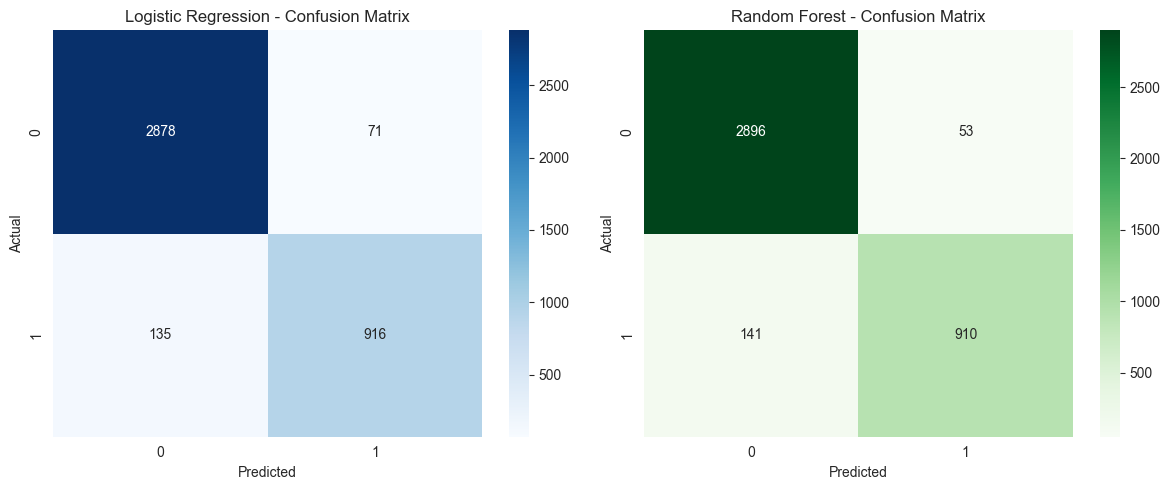

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lr_cm = confusion_matrix(y_val, lr_val_pred)
rf_cm = confusion_matrix(y_val, rf_val_pred)

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


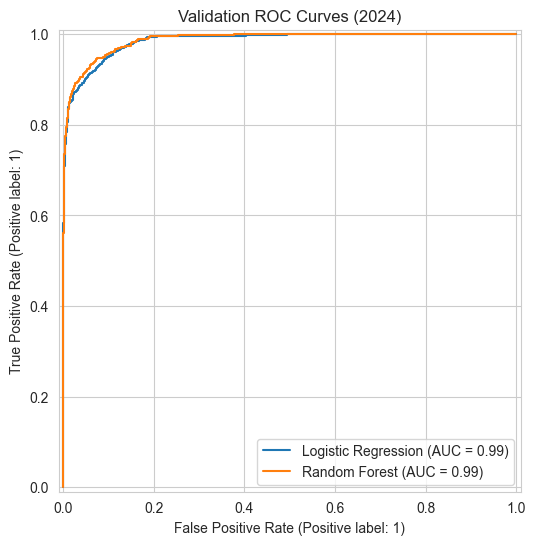

In [22]:

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_val, lr_val_prob, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_val, rf_val_prob, name='Random Forest', ax=ax)
ax.set_title('Validation ROC Curves (2024)')
plt.show()



## 12. Model interpretation

Interpretability outputs:
- Logistic Regression: top positive and negative coefficients
- Random Forest: feature importance ranking


In [23]:

# Logistic Regression coefficients
lr_feature_names = best_lr.named_steps['preprocess'].get_feature_names_out()
lr_coefs = best_lr.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({'feature': lr_feature_names, 'coefficient': lr_coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()

top_pos = coef_df.sort_values('coefficient', ascending=False).head(15)
top_neg = coef_df.sort_values('coefficient', ascending=True).head(15)

print('Top positive Logistic Regression coefficients:')
display(top_pos[['feature', 'coefficient']])
print('Top negative Logistic Regression coefficients:')
display(top_neg[['feature', 'coefficient']])


Top positive Logistic Regression coefficients:


,feature,coefficient
12,num__rolling_mean_8,2.194139
0,num__total_crime_count,1.596083
18,cat__Community Area_6,1.446967
78,cat__Community Area_66,1.395836
44,cat__Community Area_32,1.316106
36,cat__Community Area_24,1.309151
56,cat__Community Area_44,1.194764
80,cat__Community Area_68,1.192500
61,cat__Community Area_49,1.156079
81,cat__Community Area_69,0.995899


Top negative Logistic Regression coefficients:


,feature,coefficient
54,cat__Community Area_42,-1.233378
85,cat__Community Area_73,-1.093487
27,cat__Community Area_15,-1.059068
50,cat__Community Area_38,-0.874430
28,cat__Community Area_16,-0.846626
52,cat__Community Area_40,-0.841488
47,cat__Community Area_35,-0.708331
43,cat__Community Area_31,-0.703323
89,cat__Community Area_77,-0.693876
82,cat__Community Area_70,-0.661022


In [24]:

# Random Forest feature importances
rf_feature_names = best_rf.named_steps['preprocess'].get_feature_names_out()
rf_importances = best_rf.named_steps['model'].feature_importances_

rf_imp_df = (
    pd.DataFrame({'feature': rf_feature_names, 'importance': rf_importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

rf_imp_df.head(20)


,feature,importance
0,num__rolling_mean_8,0.179956
1,num__total_crime_count,0.169146
2,num__rolling_mean_4,0.149101
3,num__lag_2,0.145798
4,num__lag_1,0.138416
5,num__battery_count,0.067065
6,num__theft_count,0.044171
7,num__burglary_count,0.025388
8,num__arrest_rate,0.005835
9,num__week_of_year,0.005413


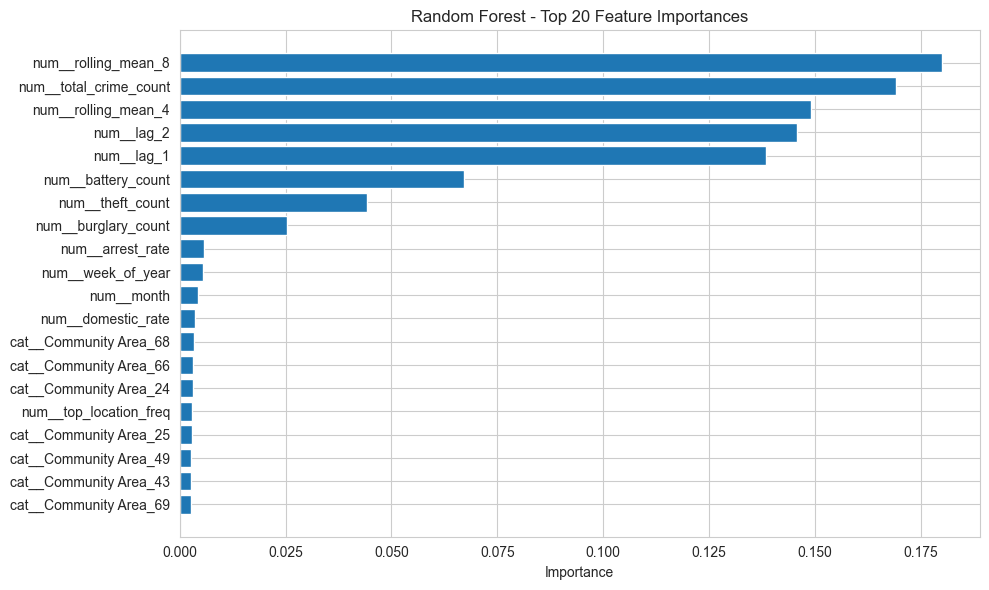

In [25]:

plt.figure(figsize=(10, 6))
plot_df = rf_imp_df.head(20).iloc[::-1]
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Random Forest - Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 13. Save artifacts for handoff

Artifacts saved for teammate handoff:
- best Logistic Regression pipeline
- best Random Forest pipeline
- selected feature list/schema
- hyperparameter search results
- model comparison table
- best validation metrics summary JSON

In [26]:
artifact_dir = Path('artifacts')
model_dir = artifact_dir / 'models'
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_lr, model_dir / 'best_logistic_regression.joblib')
joblib.dump(best_rf, model_dir / 'best_random_forest.joblib')

feature_schema = {
    'feature_columns': feature_cols,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'target_column': target_col,
    'unit_of_analysis': 'Community Area + Week',
    'aggregation_week_definition': 'Monday-start week via Date.dt.to_period("W-SUN").dt.start_time',
    'label_definition': 'next_week_crime_count >= weekly 75th percentile across community areas',
    'train_period': ['2015-01-01', '2023-12-31'],
    'validation_period': ['2024-01-01', '2024-12-31'],
    'future_test_note': 'Future test data (e.g., 2025+) is not present in this parquet and should be evaluated separately.',
}

with open(artifact_dir / 'feature_schema.json', 'w') as f:
    json.dump(feature_schema, f, indent=2)

lr_results_df.to_csv(artifact_dir / 'logistic_tuning_results.csv', index=False)
rf_results_df.to_csv(artifact_dir / 'rf_tuning_results.csv', index=False)
comparison_df.to_csv(artifact_dir / 'validation_comparison.csv', index=False)

best_validation_metrics = {
    'LogisticRegression': {
        'best_params': best_lr_params,
        'validation_metrics': best_lr_metrics,
    },
    'RandomForest': {
        'best_params': best_rf_params,
        'validation_metrics': best_rf_metrics,
    },
}

with open(artifact_dir / 'best_validation_metrics.json', 'w') as f:
    json.dump(best_validation_metrics, f, indent=2)

print('Saved artifacts:')
for p in sorted(artifact_dir.rglob('*')):
    if p.is_file():
        print('-', p)

Saved artifacts:
- artifacts/feature_schema.json
- artifacts/logistic_tuning_results.csv
- artifacts/models/best_logistic_regression.joblib
- artifacts/models/best_random_forest.joblib
- artifacts/rf_tuning_results.csv
- artifacts/validation_comparison.csv


## Limitations and handoff notes

- This notebook is for baseline model development and validation only.
- No final test evaluation is performed here.
- Downstream teammates should apply the saved feature schema consistently.
- Any future test or deployment data must follow the same Community Area + Week aggregation logic (including Monday-start week definition).
- Future evaluation on 2025 or newer data should be done in a separate notebook or script.